<a href="https://colab.research.google.com/github/Nikesh5005/ML_PROJ/blob/main/Loan_Default_Prediction_System_data_preprocess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [82]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [84]:
df = pd.read_csv("/content/drive/MyDrive/loan_data (1).csv")
df


,person_age,person_income,person_emp_length,person_home_ownership,loan_amnt,loan_intent,loan_grade,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,cb_person_default_on_file,loan_status
0,39,32627,0.3,MORTGAGE,5511,EDUCATION,D,9.87,0.17,21,N,1
1,33,40810,21.3,RENT,14469,DEBTCONSOLIDATION,D,8.91,0.35,17,N,0
2,41,34254,8.0,MORTGAGE,2222,DEBTCONSOLIDATION,A,5.00,0.06,24,N,1
3,50,52378,10.2,MORTGAGE,1733,HOMEIMPROVEMENT,A,5.00,0.03,28,N,1
4,32,100539,5.9,MORTGAGE,6380,DEBTCONSOLIDATION,D,8.87,0.06,13,Y,1
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,48,61864,11.2,OWN,11044,MEDICAL,E,11.88,0.18,29,N,1
9996,18,112018,NaN,RENT,2223,MEDICAL,E,11.89,0.02,0,Y,1
9997,27,61513,6.7,RENT,14479,MEDICAL,D,9.42,0.24,12,N,1
9998,39,137052,4.9,RENT,12506,DEBTCONSOLIDATION,C,6.71,0.09,23,Y,1


In [85]:
df.columns

Index(['person_age', 'person_income', 'person_emp_length',
       'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_grade',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'cb_person_default_on_file', 'loan_status'],
      dtype='object')

In [86]:
df.isnull().any()

,0
person_age,False
person_income,False
person_emp_length,True
person_home_ownership,False
loan_amnt,False
loan_intent,False
loan_grade,False
loan_int_rate,False
loan_percent_income,False
cb_person_cred_hist_length,False


In [87]:
df['loan_status'].value_counts(normalize=True)

,proportion
loan_status,
1,0.6327
0,0.3673


<Axes: xlabel='loan_status', ylabel='count'>

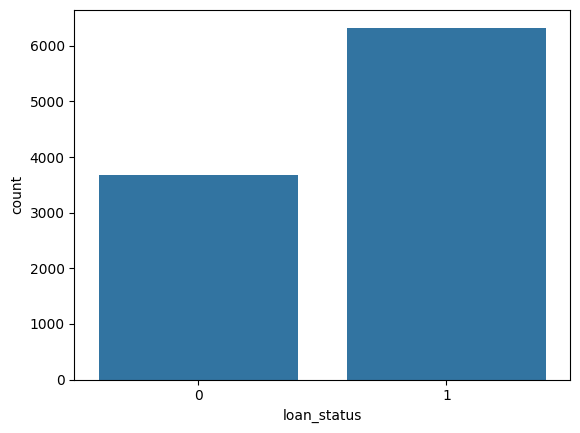

In [88]:
sns.countplot(data=df ,  x='loan_status')

by seeing the distribution we can see that there is a minor class imbalance with 63:36 ratio , how ever it is not extreme

<Axes: xlabel='person_age', ylabel='Count'>

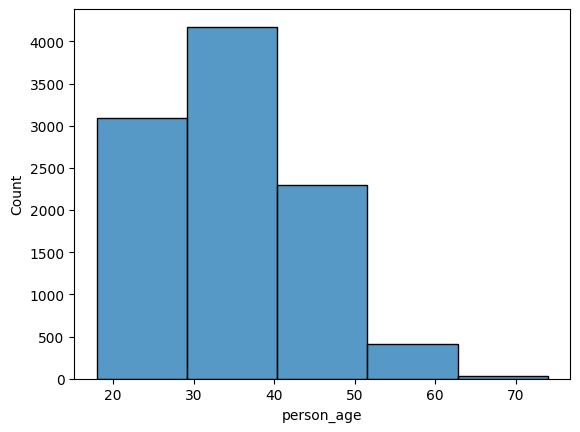

In [89]:
sns.histplot(data=df, x='person_age',bins=5)

<Axes: xlabel='loan_amnt'>

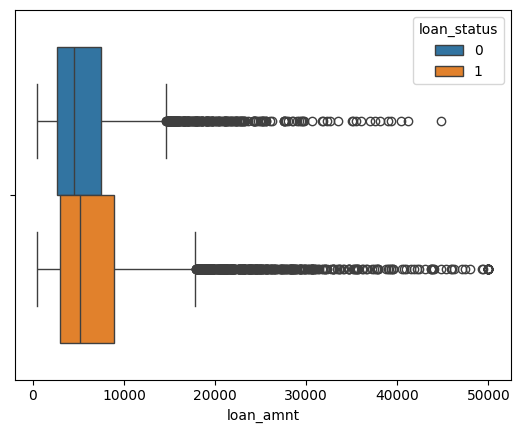

In [90]:
num_column=df.select_dtypes(include='number').columns.to_list()
sns.boxplot(data=df,x='loan_amnt',hue='loan_status')

we can see that the midian of loan_status=1(defaulters) have a a bit higher median then non defaulters which tells people who take higher loan amount are more likely to be defaulters, moreover we can see distributions overlaps loan_amnt isnt the strong pradictor

In [91]:
df['person_emp_length'].isnull().sum()

np.int64(497)

<Axes: xlabel='person_emp_length'>

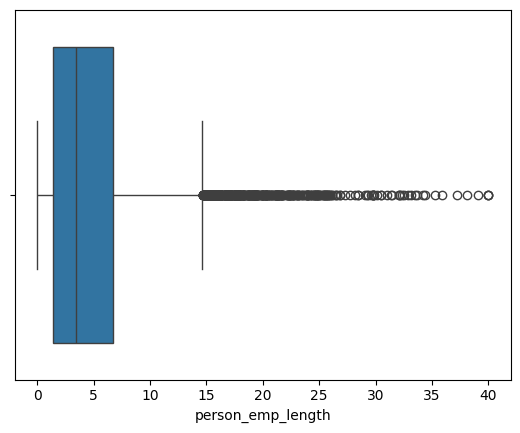

In [92]:
sns.boxplot(data=df, x='person_emp_length')

In [93]:
df['loan_percent_income'].describe()

,loan_percent_income
count,10000.000000
mean,0.158880
std,0.176749
min,0.000000
25%,0.050000
50%,0.100000
75%,0.200000
max,1.000000


<Axes: xlabel='loan_percent_income', ylabel='Count'>

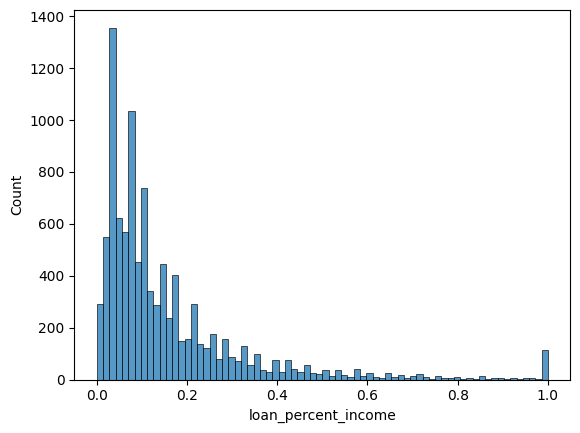

In [94]:
sns.histplot(data=df, x='loan_percent_income')

In [95]:
df["loan_percent_income"].corr(df["person_income"])

np.float64(-0.3975480500768394)

Moderate negative correlation (-0.40). As income increases, the loan-to-income ratio decreases — higher earners borrow a smaller fraction of their income relative to lower earners.

In [96]:
df.sort_values(by='loan_percent_income', ascending=False).head(20)

,person_age,person_income,person_emp_length,person_home_ownership,loan_amnt,loan_intent,loan_grade,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,cb_person_default_on_file,loan_status
4931,18,22004,2.3,MORTGAGE,35506,EDUCATION,D,10.32,1.0,0,N,1
1088,32,10000,18.6,RENT,16687,PERSONAL,D,10.25,1.0,13,N,1
7688,32,14070,5.4,RENT,18335,DEBTCONSOLIDATION,D,8.69,1.0,11,N,1
1161,57,27353,0.5,OWN,50000,DEBTCONSOLIDATION,A,5.00,1.0,30,N,1
1166,48,22872,6.9,RENT,26170,HOMEIMPROVEMENT,D,12.05,1.0,29,Y,1
9670,36,20145,0.7,RENT,21068,MEDICAL,C,7.62,1.0,16,N,1
4724,34,39945,10.3,RENT,46224,MEDICAL,B,5.00,1.0,13,N,1
4730,23,11732,7.0,MORTGAGE,15980,DEBTCONSOLIDATION,A,5.00,1.0,6,N,1
1153,21,11086,11.8,OWN,13363,PERSONAL,B,5.29,1.0,2,N,1
5238,36,35224,1.3,MORTGAGE,43980,DEBTCONSOLIDATION,C,8.32,1.0,17,N,1


In [97]:
df['person_income'].median()

49488.5

approx 115 people have exactly 1.0 **loan_percent_income** means the loan is 100% of there yearly income. And we can also see that people having **loan_percent_income** >0.80 have low  annual income , as 50% of the total people have income more then 50k , but people having **loan_percent_income** >0.80 ranges between 10K-30K

<Axes: xlabel='loan_status', ylabel='loan_percent_income'>

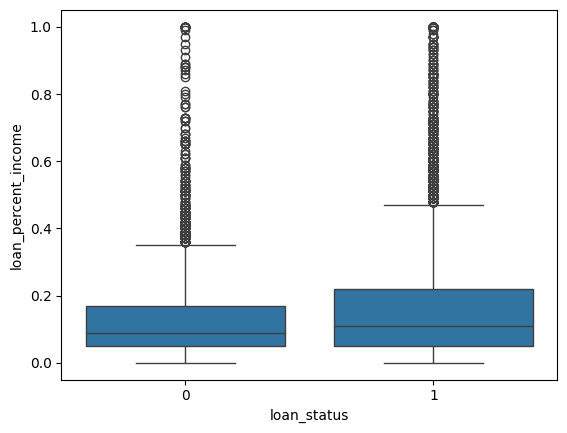

In [98]:
sns.boxplot(data=df, x='loan_status', y='loan_percent_income')

From the above boxplot we can observe that  defaulters tend to ave higher medain loan_percent_income then non defaulters, here feature **loan_percent_income** can play a quite good role in pradicting **loan_status**

In [99]:
df['cb_person_default_on_file'].value_counts()

,count
cb_person_default_on_file,
N,8451
Y,1549


In [100]:
ct=pd.crosstab(df['cb_person_default_on_file'], df['loan_status'], normalize='index')
ct

loan_status,0,1
cb_person_default_on_file,,
N,0.388238,0.611762
Y,0.253066,0.746934


Text(70.72222222222221, 0.5, 'cb_person_default_on_file')

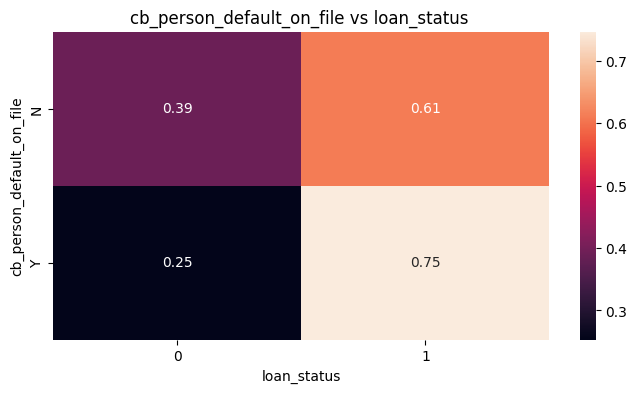

In [102]:
plt.figure(figsize=(8,4))
sns.heatmap(ct,annot=True)
plt.title("cb_person_default_on_file vs loan_status ")
plt.xlabel("loan_status")
plt.ylabel("cb_person_default_on_file")

One of the most significant observations is that the **cb_person_default_on_file** feature, which indicates whether a customer has previously defaulted on a loan, shows a strong relationship with the target variable. Customers with a history of default are considerably more likely to default again, whereas those with no previous default history are much less likely to default. This suggests that **cb_person_default_on_file** is a strong predictor of loan default and is likely to contribute significantly to the model's predictive performance.


In [104]:
df['person_income'].describe()

,person_income
count,10000.000000
mean,59177.512900
std,38960.732065
min,10000.000000
25%,32951.500000
50%,49488.500000
75%,74332.750000
max,500000.000000


<Axes: xlabel='person_income', ylabel='Count'>

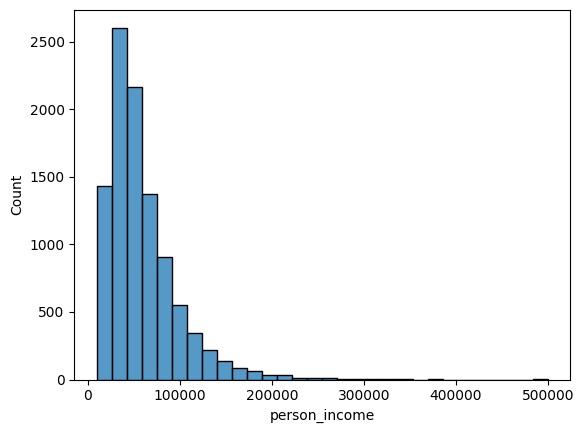

In [108]:
sns.histplot(data=df , x='person_income',bins=30)

 It means incomes are widely spread — most people(roughly 68%)fall within roughly 20k to 100K (1st std), but the max of $500k shows there are wealthy outliers pulling the std up. The data is right-skewed , where median< mean